# 04 — YOLO Model Evaluation

Evaluate the trained YOLO26s model on the BDD100K validation dataset.

### Objectives
- Load the best trained model checkpoint
- Evaluate the model on the validation set
- Measure Precision and Recall
- Measure mAP50 and mAP50-95
- Analyze per-class performance
- Review the confusion matrix and evaluation plots

### Project Roadmap
**Dataset Exploration → Data Preparation → YOLO Training → Evaluation → Inference → Driving Risk Analysis**

> **Current Stage:** Model Evaluation

## 1. Imports and Configuration

Import the required libraries and define the project paths and evaluation settings used throughout this notebook.

In [ ]:
from ultralytics import YOLO
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Image, display


In [2]:

# Project paths
BEST_MODEL_PATH = Path("../runs/runs/yolo26s_main/weights/best.pt")
DATA_YAML = Path("../data/bdd100k/dataset.yaml")

# Output directories
TRAIN_RUN_DIR = Path("../runs/runs/yolo26s_main")
VAL_RUN_DIR = Path("../runs/detect/val")

# Evaluation settings
IMG_SIZE = 512
BATCH_SIZE = 2
DEVICE = 0
WORKERS = 0

## 2. Load the Best Trained Model

Load the best YOLO26s checkpoint obtained during the 50-epoch training process.
This checkpoint will be used for model evaluation on the BDD100K validation set.

In [3]:
# Check that the trained model exists
print("Model path:", BEST_MODEL_PATH)
print("Model exists:", BEST_MODEL_PATH.exists())

Model path: ..\runs\runs\yolo26s_main\weights\best.pt
Model exists: True


In [4]:
# Load the best trained model
model = YOLO(BEST_MODEL_PATH)

print("Best model loaded successfully.")

Best model loaded successfully.


## 3. Final Validation

Evaluate the best YOLO26s checkpoint on the complete BDD100K validation set.

The evaluation measures:
- Precision
- Recall
- mAP50
- mAP50-95
- Per-class detection performance

In [5]:
# Evaluate the best model on the validation set
metrics = model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    amp=False,
    plots=True
)

Ultralytics 8.4.126  Python-3.12.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
YOLO26s summary (fused): 122 layers, 9,469,050 parameters, 0 gradients, 20.8 GFLOPs
WARNING val: Slow image access detected (ping: 14.110.5 ms, read: 2.11.1 MB/s, size: 52.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning D:\Yasna-ML-Projects\Automotive-YOLO-Object-Detection\data\bdd100k\labels\100k\val.cache... 10000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5000/5000 11.3it/s 7:23.1sss
                   all      10000     185526      0.678      0.426      0.462      0.256
                   car       9879     102506      0.732      0.694      0.746      0.451
                 truck       2689       4245      0.644      0.527      0.579      0.416
   

## 4. Overall Evaluation Metrics

The best YOLO26s model was evaluated on the complete BDD100K validation set containing **10,000 images** and **185,526 object instances**.

### Overall Performance

- **Precision:** 0.678
- **Recall:** 0.426
- **mAP50:** 0.462
- **mAP50-95:** 0.256

The model achieves relatively strong precision, while recall is lower. This indicates that the model is generally reliable when it detects an object, but missed detections remain an important limitation.

The difference between mAP50 and mAP50-95 also shows that detection performance decreases under stricter IoU requirements.

## 5. Per-Class Performance

In [6]:
# Per-class evaluation results
class_results = pd.DataFrame({
    "Class": [
        "car", "truck", "bus", "train", "person",
        "rider", "bike", "motor", "traffic light", "traffic sign"
    ],
    "Precision": [
        0.732, 0.644, 0.634, 1.000, 0.693,
        0.624, 0.547, 0.649, 0.604, 0.659
    ],
    "Recall": [
        0.694, 0.527, 0.498, 0.000, 0.448,
        0.319, 0.334, 0.257, 0.607, 0.571
    ],
    "mAP50": [
        0.746, 0.579, 0.549, 0.000, 0.524,
        0.342, 0.348, 0.336, 0.592, 0.605
    ],
    "mAP50-95": [
        0.451, 0.416, 0.420, 0.000, 0.247,
        0.165, 0.172, 0.166, 0.216, 0.308
    ]
})

class_results

,Class,Precision,Recall,mAP50,mAP50-95
0,car,0.732,0.694,0.746,0.451
1,truck,0.644,0.527,0.579,0.416
2,bus,0.634,0.498,0.549,0.420
3,train,1.000,0.000,0.000,0.000
4,person,0.693,0.448,0.524,0.247
5,rider,0.624,0.319,0.342,0.165
6,bike,0.547,0.334,0.348,0.172
7,motor,0.649,0.257,0.336,0.166
8,traffic light,0.604,0.607,0.592,0.216
9,traffic sign,0.659,0.571,0.605,0.308


### Per-Class Analysis

The model shows clear differences in performance across object classes.

- **Car** achieved the strongest performance with an mAP50 of 0.746 and mAP50-95 of 0.451.
- **Traffic sign** and **traffic light** also achieved relatively strong detection performance.
- **Truck**, **bus**, and **person** showed moderate performance.
- **Rider**, **bike**, and **motor** were more difficult for the model, with lower recall and mAP scores.
- **Train** should not be interpreted as a normal model failure because the validation set contains only 15 train instances, which is insufficient for a reliable class-level evaluation.

These differences are consistent with the strong class imbalance observed during BDD100K dataset exploration. Frequent classes such as cars provide substantially more training examples, while rare classes provide much less information for the model to learn from.

### 5.1 mAP50 by Class

Compare the mAP50 performance across the 10 BDD100K object classes.

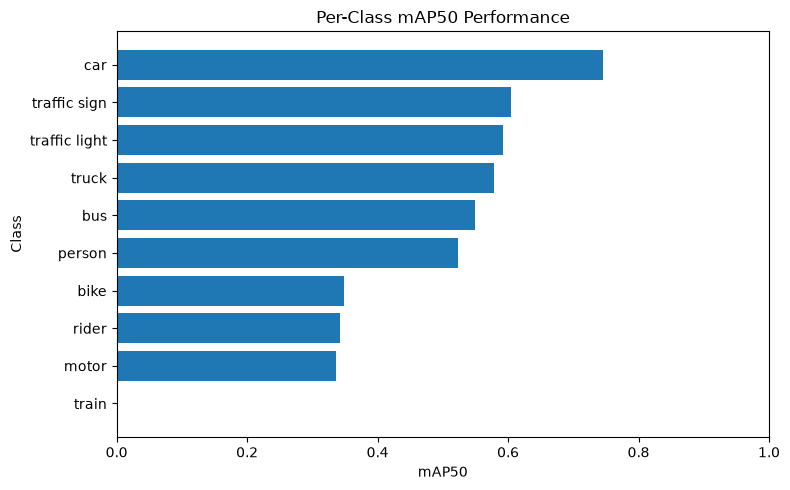

In [17]:
# Sort classes by mAP50
map50_data = class_results.sort_values("mAP50", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(map50_data["Class"], map50_data["mAP50"])

plt.xlabel("mAP50")
plt.ylabel("Class")
plt.title("Per-Class mAP50 Performance")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

### 5.2 Precision vs Recall

Compare Precision and Recall across the 10 BDD100K object classes.

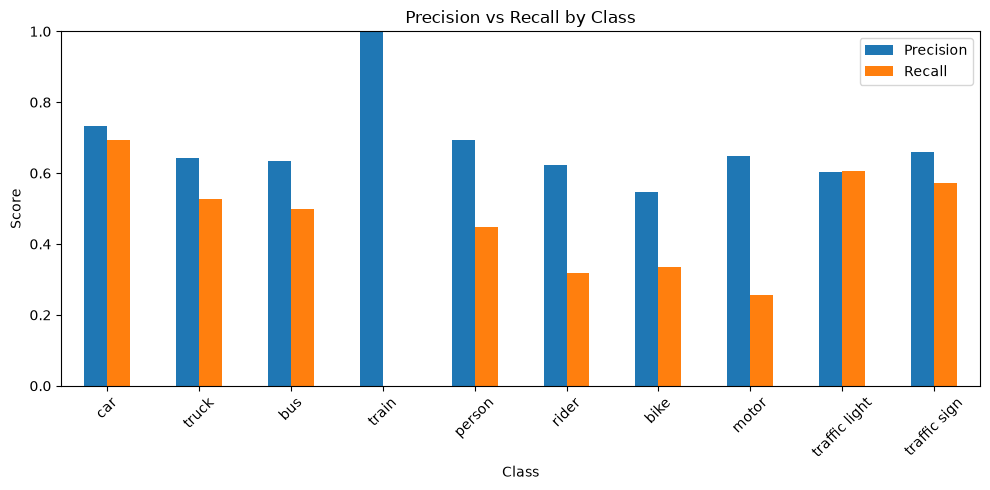

In [16]:
# Compare Precision and Recall for each class
pr_data = class_results.set_index("Class")[["Precision", "Recall"]]

pr_data.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Score")
plt.xlabel("Class")
plt.title("Precision vs Recall by Class")
plt.ylim(0, 1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 5.3 mAP50-95 by Class

Compare the stricter mAP50-95 performance across the 10 BDD100K object classes.

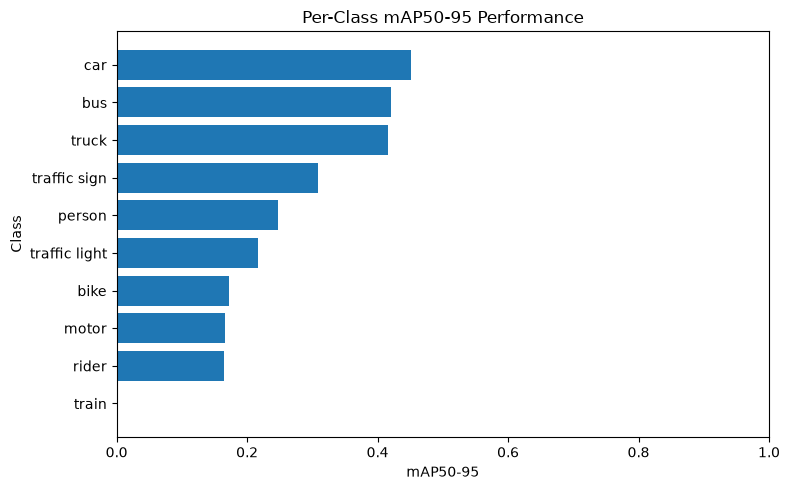

In [15]:
# Sort classes by mAP50-95
map5095_data = class_results.sort_values("mAP50-95", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    map5095_data["Class"],
    map5095_data["mAP50-95"]
)

ax.set_xlabel("mAP50-95")
ax.set_ylabel("Class")
ax.set_title("Per-Class mAP50-95 Performance")
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 6. Confusion Matrix Analysis


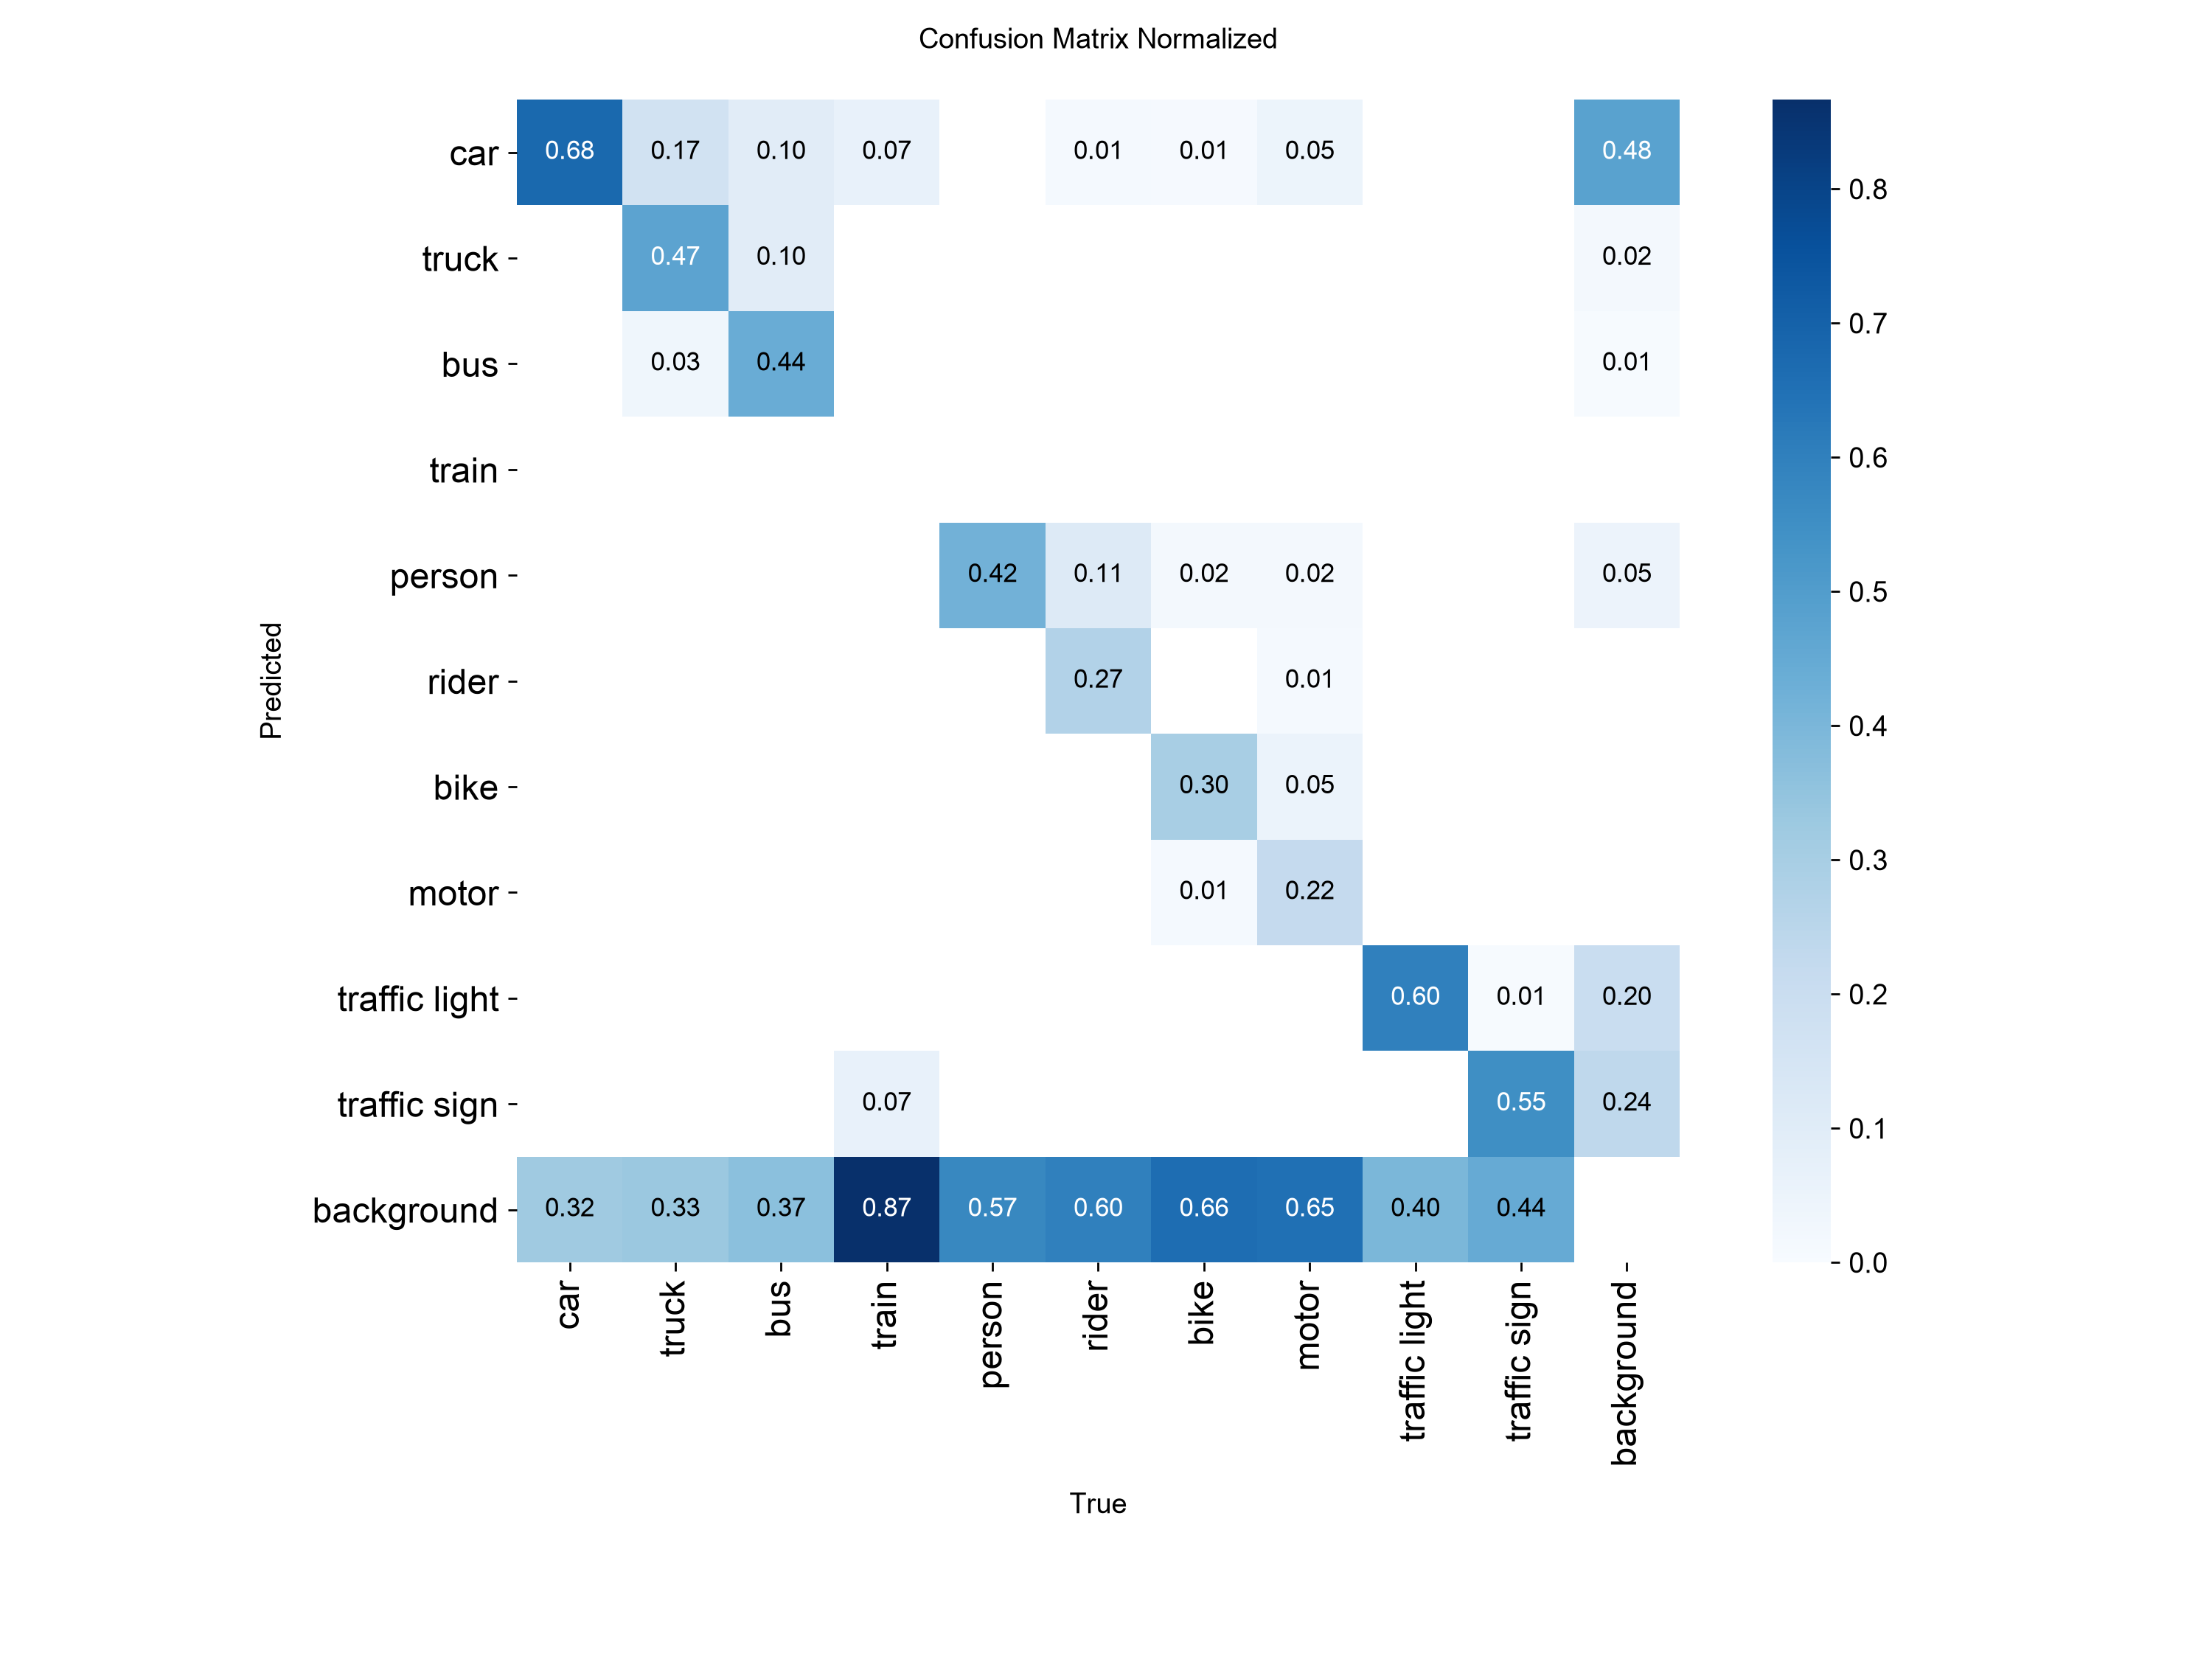

In [ ]:



display(
    Image(
        filename="../runs/detect/val/confusion_matrix_normalized.png",
        width=700
    )
)

### Confusion Matrix Interpretation

The normalized confusion matrix shows that the model performs better on frequent classes such as **car**, **traffic light**, and **traffic sign**.

A large proportion of less frequent or more difficult objects are predicted as **background**, especially for **person**, **rider**, **bike**, and **motor**. This indicates that missed detections are one of the main limitations of the model.

The **train** class cannot be reliably evaluated because the validation set contains only a very small number of train instances.

Overall, the confusion matrix confirms that class imbalance and object difficulty significantly affect detection performance.

## 7. Precision-Recall and F1 Curves

Precision-Recall and F1 curves provide additional insight into the detection performance of the trained model.

These curves help analyze the trade-off between precision and recall and identify the confidence thresholds that maximize detection quality.

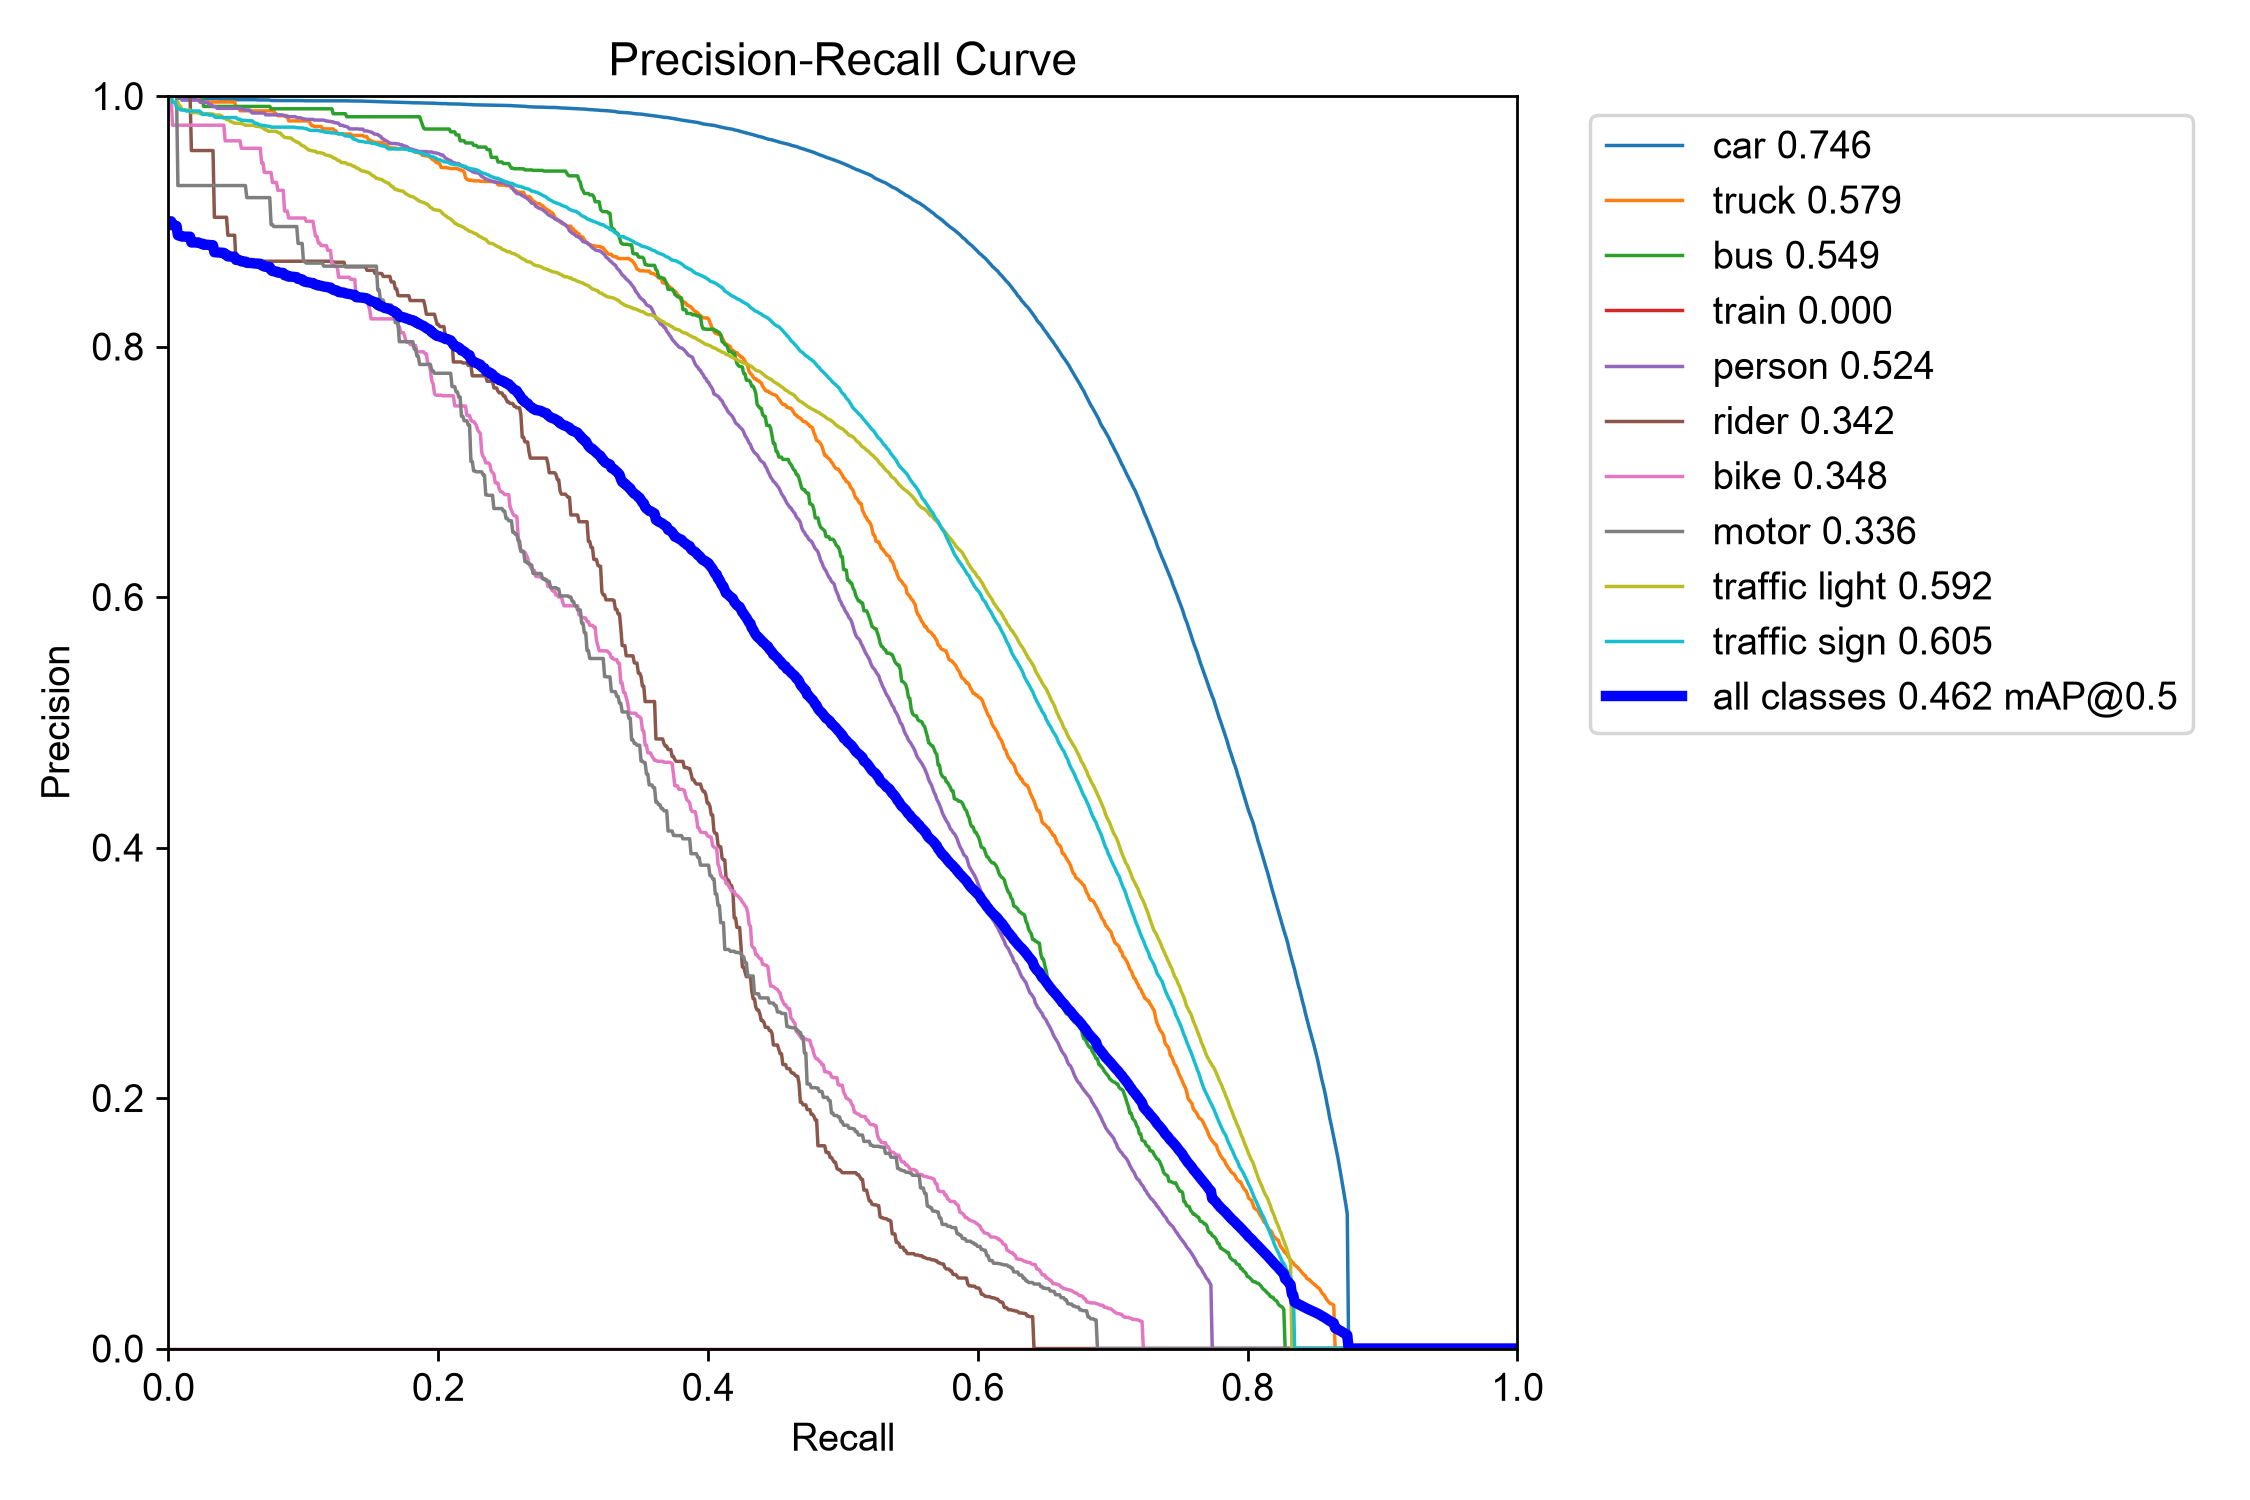

In [11]:
# Display Precision-Recall Curve
display(
    Image(
        filename=str(TRAIN_RUN_DIR / "BoxPR_curve.png"),
        width=650
    )
)

### Precision-Recall Curve Analysis

The Precision-Recall curve shows clear differences in detection performance across object classes.

- **Car** achieves the strongest performance with an mAP50 of **0.746**.
- **Traffic sign (0.605)** and **traffic light (0.592)** also show relatively strong performance.
- **Truck (0.579)**, **bus (0.549)**, and **person (0.524)** achieve moderate performance.
- **Rider (0.342)**, **bike (0.348)**, and **motor (0.336)** show considerably lower performance.
- **Train** has an mAP50 of **0.000**, but this result is not reliable because only 15 train instances are available in the validation set.
- Across all classes, the model achieves an overall **mAP50 of 0.462**.

The curve confirms that the model performs substantially better on frequent classes, while rare and difficult classes remain challenging.

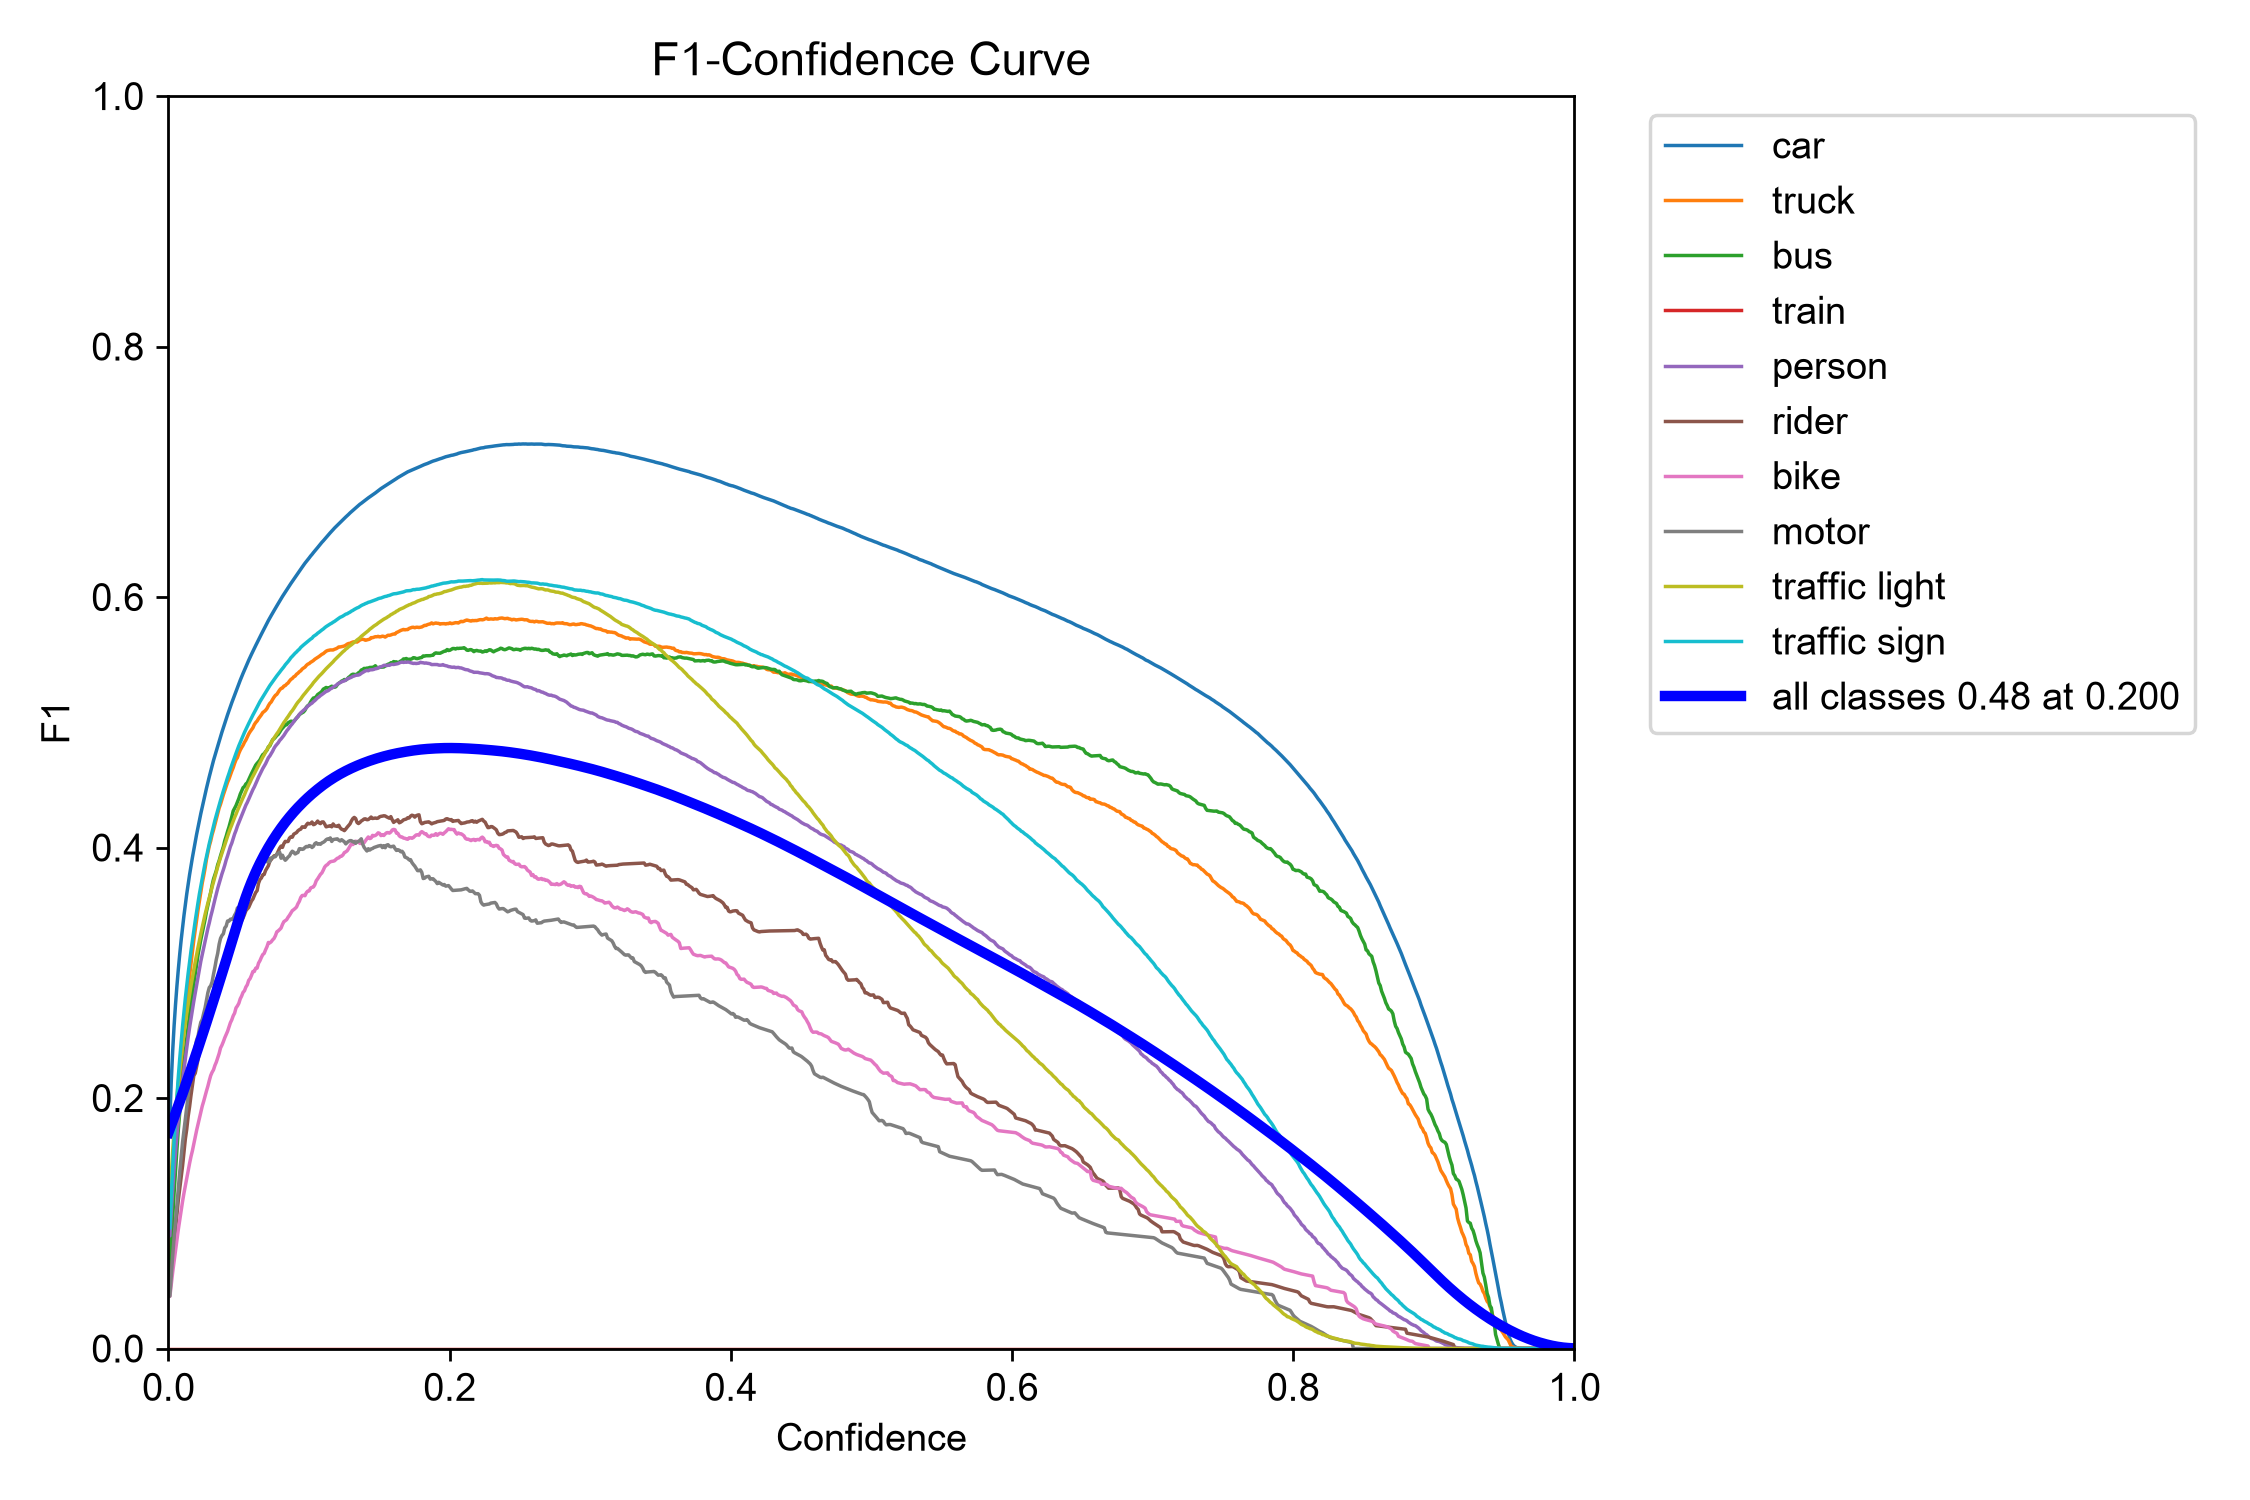

In [12]:
# Display F1-Confidence Curve
display(
    Image(
        filename=str(TRAIN_RUN_DIR / "BoxF1_curve.png"),
        width=650
    )
)

### F1-Confidence Curve Analysis

The F1-Confidence curve shows how the balance between Precision and Recall changes as the confidence threshold increases.

- Across all classes, the highest overall F1 score is approximately **0.48** at a confidence threshold of **0.20**.
- **Car** achieves the strongest F1 performance among the evaluated classes.
- **Traffic sign**, **traffic light**, **truck**, and **bus** also show relatively strong F1 performance.
- **Rider**, **bike**, and **motor** achieve lower F1 scores, consistent with the previous evaluation results.
- At very high confidence thresholds, F1 decreases substantially because the model becomes more selective and misses more objects.

A confidence threshold around **0.20** provides the best overall Precision-Recall balance on this validation set.

## 8. Conclusion

The best YOLO26s model was successfully evaluated on the BDD100K validation dataset containing **10,000 images** and **185,526 object instances**.

### Overall Performance

- **Precision:** 0.678
- **Recall:** 0.426
- **mAP50:** 0.462
- **mAP50-95:** 0.256
- **Best overall F1:** approximately 0.48 at a confidence threshold of 0.20

### Key Findings

- **Car** achieved the strongest detection performance with an mAP50 of **0.746**.
- **Traffic signs**, **traffic lights**, **trucks**, and **buses** also showed relatively strong performance.
- **Rider**, **bike**, and **motor** were more challenging and showed lower recall and mAP scores.
- Performance differences across classes are strongly associated with the class imbalance observed in the BDD100K dataset.
- The confusion matrix shows that missed detections, particularly predictions associated with the background, remain an important limitation.
- The train class cannot be reliably evaluated because only **15 train instances** are present in the validation set.

Overall, the evaluation provides a clear baseline for using the trained model on real driving images and videos.

### Next Step

**Notebook 05 — YOLO Inference**

The next stage will use the trained `best.pt` model to detect road objects in unseen driving images and videos before moving to Driving Risk Analysis.